# SPACESHIP TITANIC

In [21]:
import copy
import random
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import seaborn as sns
import matplotlib.pyplot as plt

from torch.utils.data import TensorDataset, DataLoader
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler

## Data Import

In [22]:
train_data = pd.read_csv("./data/train.csv")
test_data = pd.read_csv("./data/test.csv")

## Data Preprocess
- Transported/CryoSleep 轉成 0/1
- PassengerId、Name、Cabin 原始欄位不直接當特徵
- PassengerId / Name 會衍生群組特徵
- 規則式 missing imputation：spend/CryoSleep、Passenger group/surname/cabin deck 補 HomePlanet、VIP hard false
- RoomService / FoodCourt / ShoppingMall / Spa / VRDeck 會衍生消費聚合特徵
- Age 會另外切成幾個 age bins
- 會補 missingness indicators
- Cabin 缺失值補上 Missing//Missing
    - 把 Cabin 拆成 CabinDeck、CabinNum、CabinSide

In [23]:
def to_binary(series):
    return series.astype(str).map({"False": 0, "True": 1}).astype(float)


def fill_missing_from_unique_group(df, group_key, col):
    known = pd.DataFrame({"group": group_key, "value": df[col]}).dropna()
    unique_counts = known.groupby("group")["value"].nunique()
    reliable_groups = unique_counts[unique_counts == 1].index
    fill_values = (
        known[known["group"].isin(reliable_groups)]
        .drop_duplicates("group")
        .set_index("group")["value"]
    )
    missing_mask = df[col].isna()
    fill_series = group_key.map(fill_values)
    filled_mask = missing_mask & fill_series.notna()
    df.loc[filled_mask, col] = fill_series.loc[filled_mask]
    return filled_mask.astype(float)


def print_rule_imputation_summary(label, df):
    rule_cols = [col for col in df.columns if col.endswith("RuleFilled")]
    missing_check_cols = [
        "HomePlanet",
        "CryoSleep",
        "Destination",
        "Age",
        "VIP",
        "RoomService",
        "FoodCourt",
        "ShoppingMall",
        "Spa",
        "VRDeck",
        "CabinNum",
    ]
    existing_missing_cols = [col for col in missing_check_cols if col in df.columns]
    print(f"\n[{label}] rule-filled counts")
    if rule_cols:
        print(df[rule_cols].sum().astype(int).sort_values(ascending=False).to_string())
    else:
        print("No RuleFilled columns found.")
    print(f"\n[{label}] remaining missing counts")
    if existing_missing_cols:
        print(df[existing_missing_cols].isna().sum().astype(int).sort_values(ascending=False).to_string())
    else:
        print("No tracked columns found.")


def add_basic_features(df):
    df = df.copy()

    missing_cols = ["HomePlanet", "CryoSleep", "Cabin", "Destination", "Age", "VIP", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck", "Name"]
    for col in missing_cols:
        df[f"{col}IsMissing"] = df[col].isna().astype(float)

    passenger_group = (
        df["PassengerId"]
        .astype("string")
        .fillna("Missing")
        .str.split("_", n=1, expand=True)[0]
    )

    surname = (
        df["Name"]
        .astype("string")
        .fillna("Missing")
        .str.rsplit(" ", n=1)
        .str[-1]
    )
    cabin_for_rules = df["Cabin"].fillna("Missing//Missing").str.split("/", expand=True)
    cabin_deck_for_rules = cabin_for_rules[0]

    spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
    spend_numeric = df[spend_cols].apply(pd.to_numeric, errors="coerce")
    any_known_spend = spend_numeric.gt(0).any(axis=1)
    cryo_missing = df["CryoSleep"].isna()
    df["CryoSleepSpendRuleFilled"] = (cryo_missing & any_known_spend).astype(float)
    df.loc[cryo_missing & any_known_spend, "CryoSleep"] = False

    cryo_true = df["CryoSleep"].astype("string").eq("True")
    for col in spend_cols:
        filled_mask = cryo_true & df[col].isna()
        df[f"{col}CryoSleepRuleFilled"] = filled_mask.astype(float)
        df.loc[filled_mask, col] = 0

    df["HomePlanetGroupRuleFilled"] = fill_missing_from_unique_group(df, passenger_group, "HomePlanet")
    df["HomePlanetSurnameRuleFilled"] = fill_missing_from_unique_group(df, surname, "HomePlanet")
    homeplanet_deck_rule = df["HomePlanet"].isna() & cabin_deck_for_rules.isin(["A", "B", "C", "T", "G"])
    df["HomePlanetCabinDeckRuleFilled"] = homeplanet_deck_rule.astype(float)
    df.loc[homeplanet_deck_rule & cabin_deck_for_rules.isin(["A", "B", "C", "T"]), "HomePlanet"] = "Europa"
    df.loc[homeplanet_deck_rule & cabin_deck_for_rules.eq("G"), "HomePlanet"] = "Earth"

    vip_missing = df["VIP"].isna()
    vip_false_rule = vip_missing & (df["HomePlanet"].eq("Earth") | pd.to_numeric(df["Age"], errors="coerce").lt(13))
    df["VIPHardFalseRuleFilled"] = vip_false_rule.astype(float)
    df.loc[vip_false_rule, "VIP"] = False

    passenger_group_size = passenger_group.map(passenger_group.value_counts()).astype(float)
    df["PassengerGroupSize"] = passenger_group_size
    df["PassengerIsAlone"] = (passenger_group_size == 1).astype(float)

    age_numeric = pd.to_numeric(df["Age"], errors="coerce")
    age_bins = [-np.inf, 12, 17, 25, 40, 60, np.inf]
    age_labels = ["Child", "Teen", "YoungAdult", "Adult", "MiddleAged", "Senior"]
    df["AgeBin"] = pd.cut(age_numeric, bins=age_bins, labels=age_labels, include_lowest=True).astype("string").fillna("Missing")

    surname_group_size = surname.map(surname.value_counts()).astype(float)
    df["SurnameGroupSize"] = surname_group_size
    df["SurnameIsAlone"] = (surname_group_size == 1).astype(float)

    spend_frame = df[spend_cols].fillna(0)
    df["TotalSpend"] = spend_frame.sum(axis=1)
    df["LogTotalSpend"] = np.log1p(df["TotalSpend"])
    df["AnySpend"] = (df["TotalSpend"] > 0).astype(float)
    df["LuxurySpend"] = spend_frame[["Spa", "VRDeck"]].sum(axis=1)
    df["RegularSpend"] = spend_frame[["RoomService", "FoodCourt", "ShoppingMall"]].sum(axis=1)

    df = df.drop(columns=["PassengerId", "Name"], errors="ignore")
    cabin = df["Cabin"].fillna("Missing//Missing").str.split("/", expand=True)
    df["CabinDeck"] = cabin[0]
    df["CabinNum"] = pd.to_numeric(cabin[1], errors="coerce")
    df["CabinSide"] = cabin[2]
    df["CabinDeckSide"] = df["CabinDeck"].astype("string") + "__" + df["CabinSide"].astype("string")
    return df.drop(columns=["Cabin"])


# Split train / validation first.
X = train_data.drop(columns=["Transported"]).copy()
y = to_binary(train_data["Transported"])
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

X_train = add_basic_features(X_train)
X_val = add_basic_features(X_val)
print_rule_imputation_summary("split_train", X_train)
print_rule_imputation_summary("split_val", X_val)



[split_train] rule-filled counts
VIPHardFalseRuleFilled             94
CryoSleepSpendRuleFilled           86
HomePlanetSurnameRuleFilled        86
ShoppingMallCryoSleepRuleFilled    78
HomePlanetGroupRuleFilled          69
FoodCourtCryoSleepRuleFilled       60
RoomServiceCryoSleepRuleFilled     58
SpaCryoSleepRuleFilled             57
VRDeckCryoSleepRuleFilled          50
HomePlanetCabinDeckRuleFilled       6

[split_train] remaining missing counts
CabinNum        161
Destination     153
Age             139
FoodCourt        94
VRDeck           94
Spa              93
ShoppingMall     91
RoomService      87
CryoSleep        82
VIP              64
HomePlanet        8

[split_val] rule-filled counts
CryoSleepSpendRuleFilled           33
VIPHardFalseRuleFilled             28
ShoppingMallCryoSleepRuleFilled    18
HomePlanetSurnameRuleFilled        18
VRDeckCryoSleepRuleFilled          12
RoomServiceCryoSleepRuleFilled     10
FoodCourtCryoSleepRuleFilled       10
SpaCryoSleepRuleFilled      

## Baseline 0
先看一個最簡單的 `Transported = CryoSleep` validation accuracy
- 把 validation set 裡 CryoSleep 的缺失值，補成算出的眾數

In [24]:
# 先從 training split 的 CryoSleep 找出最常出現的值
cryo_mode = X_train["CryoSleep"].mode(dropna=True)[0]
# 把 validation split 裡 CryoSleep 的缺失值，補成剛剛算出的眾數
cryo_val = X_val["CryoSleep"].astype("string").fillna(cryo_mode)
cryo_pred = to_binary(cryo_val)
# 直接算 accuracy
acc_b0 = accuracy_score(y_val, cryo_pred >= 0.5)
print(f"Baseline 0 | Transported = CryoSleep | Acc: {acc_b0:.4f}")

Baseline 0 | Transported = CryoSleep | Acc: 0.7131


## CatBoost
CatBoost fit training split, then evaluate validation accuracy and logloss.

In [25]:
from catboost import CatBoostClassifier, Pool


def prepare_native_catboost_frame(X):
    X_native = X.copy()
    categorical_features = X_native.select_dtypes(exclude=["number"]).columns.tolist()
    for col in categorical_features:
        X_native[col] = X_native[col].astype("string").fillna("Missing").astype(str)
    return X_native, categorical_features


# CatBoost can consume categorical columns directly when we pass cat_features.
N_ESTIMATORS = 10000
LR = 0.01
MAX_DEPTH = 5
SUBSAMPLE = 0.65
COLSAMPLE_BYTREE = 0.9
CATBOOST_L2_LEAF_REG = 3.0
ESR = 200

X_train_cat, cat_categorical_features = prepare_native_catboost_frame(X_train)
X_val_cat, _ = prepare_native_catboost_frame(X_val)
train_pool = Pool(X_train_cat, y_train.astype(int), cat_features=cat_categorical_features)
val_pool = Pool(X_val_cat, y_val.astype(int), cat_features=cat_categorical_features)

print(f"feature count = {X_train_cat.shape[1]}")
print(f"categorical feature count = {len(cat_categorical_features)}")
print("categorical features:")
print(cat_categorical_features)

cat_model = CatBoostClassifier(
    iterations=N_ESTIMATORS,
    learning_rate=LR,
    depth=MAX_DEPTH,
    subsample=SUBSAMPLE,
    rsm=COLSAMPLE_BYTREE,
    l2_leaf_reg=CATBOOST_L2_LEAF_REG,
    random_seed=42,
    loss_function="Logloss",
    eval_metric="Logloss",
    bootstrap_type="Bernoulli",
    verbose=False,
    allow_writing_files=False,
    use_best_model=True,
    od_type="Iter",
    od_wait=ESR,
)
cat_model.fit(
    train_pool,
    eval_set=val_pool,
    verbose=False,
)
train_acc_cat = accuracy_score(y_train.astype(int), np.asarray(cat_model.predict(train_pool)).astype(int).ravel())
val_acc_cat = accuracy_score(y_val.astype(int), np.asarray(cat_model.predict(val_pool)).astype(int).ravel())
evals_result = cat_model.get_evals_result()
print(f"CatBoost | train acc: {train_acc_cat:.4f} | val acc: {val_acc_cat:.4f}")
print(f"best_iteration = {cat_model.get_best_iteration()}")
print(f"best_score = {cat_model.get_best_score()}")

feature count = 46
categorical feature count = 8
categorical features:
['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'AgeBin', 'CabinDeck', 'CabinSide', 'CabinDeckSide']
CatBoost | train acc: 0.8759 | val acc: 0.8166
best_iteration = 4372
best_score = {'learn': {'Logloss': 0.27033631049983875}, 'validation': {'Logloss': 0.3556577605378652}}


# CatBoost Native Categorical + OOF Threshold Search
- 直接把 categorical columns 交給 CatBoost 的 `cat_features`
- 不再做 one-hot encoding
- 不再用 SelectKBest 篩掉欄位
- 直接用外層 X_val 做 early stopping，看收斂狀況
- 用 OOF probabilities 找最佳 threshold
- 最後用 full training data 重訓再輸出 submission

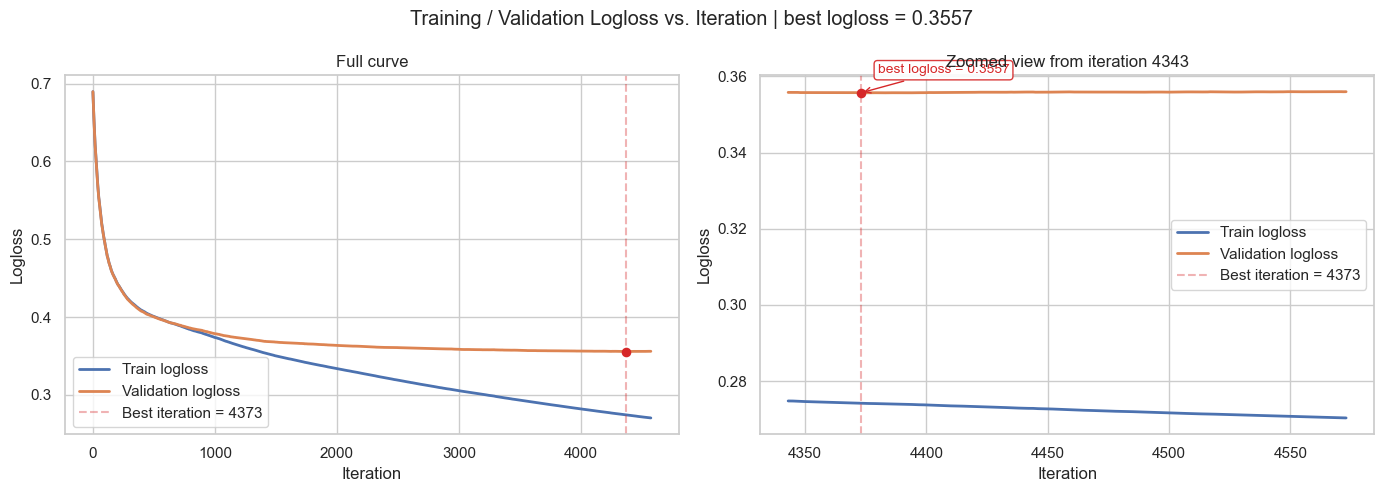

In [26]:
# evals_result is populated in the previous CatBoost training cell.
def _extract_catboost_metric_series(evals_result, metric_name="Logloss"):
    train_key = "learn" if "learn" in evals_result else next(iter(evals_result))
    val_key = next((key for key in evals_result.keys() if key != train_key), train_key)
    train_metrics = evals_result[train_key]
    val_metrics = evals_result[val_key]
    if metric_name not in train_metrics:
        metric_name = next(iter(train_metrics))
    return train_metrics[metric_name], val_metrics[metric_name]

train_logloss, val_logloss = _extract_catboost_metric_series(evals_result)
rounds = np.arange(1, len(train_logloss) + 1)
best_iteration = cat_model.get_best_iteration()
best_round = (best_iteration + 1) if best_iteration is not None and best_iteration >= 0 else int(np.argmin(val_logloss) + 1)
best_idx = best_round - 1
best_val_logloss = val_logloss[best_idx]
zoom_start = max(1, best_round - 30)
zoom_mask = rounds >= zoom_start
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rounds, train_logloss, label='Train logloss', linewidth=2)
axes[0].plot(rounds, val_logloss, label='Validation logloss', linewidth=2)
axes[0].axvline(best_round, color='tab:red', linestyle='--', alpha=0.35, label=f'Best iteration = {best_round}')
axes[0].scatter(best_round, best_val_logloss, color='tab:red', s=35, zorder=3)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Logloss')
axes[0].set_title('Full curve')
axes[0].legend()

axes[1].plot(rounds[zoom_mask], np.array(train_logloss)[zoom_mask], label='Train logloss', linewidth=2)
axes[1].plot(rounds[zoom_mask], np.array(val_logloss)[zoom_mask], label='Validation logloss', linewidth=2)
axes[1].axvline(best_round, color='tab:red', linestyle='--', alpha=0.35, label=f'Best iteration = {best_round}')
axes[1].scatter(best_round, best_val_logloss, color='tab:red', s=35, zorder=3)
axes[1].annotate(
    f'best logloss = {best_val_logloss:.4f}',
    xy=(best_round, best_val_logloss),
    xytext=(12, 14),
    textcoords='offset points',
    fontsize=10,
    color='tab:red',
    bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='tab:red', alpha=0.9),
    arrowprops=dict(arrowstyle='->', color='tab:red', lw=1),
)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Logloss')
axes[1].set_title(f'Zoomed view from iteration {zoom_start}')
axes[1].legend()

fig.suptitle(f'Training / Validation Logloss vs. Iteration | best logloss = {best_val_logloss:.4f}')
fig.tight_layout()
plt.show()

## Final Run
Retrain a single CatBoost model on the full training data, search OOF threshold, and submit from inside the notebook.

In [27]:
# Final run: retrain a single native-categorical CatBoost model on the full training set, search an OOF threshold, write submission.csv, and submit from inside this notebook.
import subprocess
import sys
import shutil
from pathlib import Path
from catboost import CatBoostClassifier, Pool


def prepare_native_catboost_frame(X):
    X_native = X.copy()
    categorical_features = X_native.select_dtypes(exclude=["number"]).columns.tolist()
    for col in categorical_features:
        X_native[col] = X_native[col].astype("string").fillna("Missing").astype(str)
    return X_native, categorical_features


def fit_single_catboost(X_fit, y_fit, X_target, n_estimators, *, random_state=42):
    X_fit_native, categorical_features = prepare_native_catboost_frame(X_fit)
    X_target_native, _ = prepare_native_catboost_frame(X_target)
    fit_pool = Pool(X_fit_native, y_fit.astype(int), cat_features=categorical_features)
    target_pool = Pool(X_target_native, cat_features=categorical_features)

    model = CatBoostClassifier(
        iterations=n_estimators,
        learning_rate=LR,
        depth=MAX_DEPTH,
        subsample=SUBSAMPLE,
        rsm=COLSAMPLE_BYTREE,
        l2_leaf_reg=CATBOOST_L2_LEAF_REG,
        random_seed=random_state,
        loss_function="Logloss",
        eval_metric="Logloss",
        bootstrap_type="Bernoulli",
        verbose=False,
        allow_writing_files=False,
    )
    model.fit(fit_pool, verbose=False)
    return model, categorical_features, target_pool


def search_best_threshold(y_true, probas, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 197)
    y_true = np.asarray(y_true).astype(int)
    probas = np.asarray(probas)
    best_threshold = 0.5
    best_acc = -1.0
    for threshold in thresholds:
        acc = accuracy_score(y_true, probas >= threshold)
        if acc > best_acc:
            best_acc = acc
            best_threshold = float(threshold)
    return best_threshold, best_acc


def build_oof_catboost_predictions(X, y, n_estimators, *, n_splits=5, random_state=42):
    X_work = X.reset_index(drop=True)
    y_work = np.asarray(y).astype(int)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    oof_proba = np.zeros(len(X_work), dtype=float)
    categorical_counts = []
    for fold_idx, (fit_idx, eval_idx) in enumerate(skf.split(X_work, y_work)):
        X_fit = X_work.iloc[fit_idx].reset_index(drop=True)
        y_fit = y_work[fit_idx]
        X_eval = X_work.iloc[eval_idx].reset_index(drop=True)
        y_eval = y_work[eval_idx]
        model, categorical_features, eval_pool = fit_single_catboost(
            X_fit,
            y_fit,
            X_eval,
            n_estimators,
            random_state=random_state + fold_idx,
        )
        fold_proba = model.predict_proba(eval_pool)[:, 1]
        oof_proba[eval_idx] = fold_proba
        categorical_counts.append(len(categorical_features))
        print(
            f"fold={fold_idx + 1}/{n_splits} | oof acc @0.5: {accuracy_score(y_eval, fold_proba >= 0.5):.4f} | "
            f"categorical: {len(categorical_features)}"
        )
    return oof_proba, categorical_counts


final_iterations = int(globals().get("best_round", N_ESTIMATORS))
print(f"final_iterations = {final_iterations}")

full_train_X = add_basic_features(train_data.drop(columns=["Transported"]).copy())
full_train_y = to_binary(train_data["Transported"])
test_raw = add_basic_features(test_data.copy())
print_rule_imputation_summary("full_train", full_train_X)
print_rule_imputation_summary("test", test_raw)

oof_proba, oof_categorical_counts = build_oof_catboost_predictions(
    full_train_X,
    full_train_y,
    final_iterations,
    n_splits=5,
    random_state=42,
)
full_train_y_int = np.asarray(full_train_y).astype(int)
oof_acc_05 = accuracy_score(full_train_y_int, oof_proba >= 0.5)
best_threshold, best_oof_acc = search_best_threshold(full_train_y_int, oof_proba)
print(f"OOF acc @0.5: {oof_acc_05:.4f}")
print(f"OOF best threshold: {best_threshold:.4f} | OOF best acc: {best_oof_acc:.4f}")
print(f"OOF categorical feature counts = {oof_categorical_counts}")

final_model, final_categorical_features, test_pool = fit_single_catboost(
    full_train_X,
    full_train_y,
    test_raw,
    final_iterations,
    random_state=42,
)
print(f"categorical feature count = {len(final_categorical_features)}")
print(final_categorical_features)

test_proba = final_model.predict_proba(test_pool)[:, 1]
test_pred = (test_proba >= best_threshold).astype(bool)

submission_path = (
    f"submission_catboost_nativecat_ruleimpv2_it{final_iterations}_th{best_threshold}"
    f"_lr{LR}_md{MAX_DEPTH}_ss{SUBSAMPLE}"
    f"_cs{COLSAMPLE_BYTREE}_l2{CATBOOST_L2_LEAF_REG}"
    f".csv"
)

sample_submission = pd.read_csv("./data/sample_submission.csv")
submission = sample_submission.copy()
submission["Transported"] = test_pred
submission.to_csv(submission_path, index=False)

print(submission.head())
print(f"saved to {submission_path} with shape {submission.shape}")

kaggle_exe = shutil.which("kaggle") or str(Path(sys.executable).with_name("kaggle"))
submit_cmd = [
    kaggle_exe,
    "competitions",
    "submit",
    "-c",
    "spaceship-titanic",
    "-f",
    submission_path,
    "-m",
    f"CatBoost native categorical / ruleimp v2 / PassengerId & Name features process / Spend features process / missingness / age bins / OOF threshold search",
]
print("Running:", " ".join(submit_cmd))
try:
    result = subprocess.run(submit_cmd, check=True, text=True, capture_output=True)
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)
except FileNotFoundError:
    print("kaggle CLI not found in this notebook kernel environment.")
except subprocess.CalledProcessError as exc:
    print("Kaggle submit failed.")
    if exc.stdout:
        print(exc.stdout)
    if exc.stderr:
        print(exc.stderr)
    raise

final_iterations = 4373

[full_train] rule-filled counts
VIPHardFalseRuleFilled             123
CryoSleepSpendRuleFilled           119
HomePlanetSurnameRuleFilled         99
ShoppingMallCryoSleepRuleFilled     96
HomePlanetGroupRuleFilled           90
FoodCourtCryoSleepRuleFilled        70
RoomServiceCryoSleepRuleFilled      68
SpaCryoSleepRuleFilled              65
VRDeckCryoSleepRuleFilled           62
HomePlanetCabinDeckRuleFilled        4

[full_train] remaining missing counts
CabinNum        199
Destination     182
Age             179
VRDeck          126
Spa             118
RoomService     113
FoodCourt       113
ShoppingMall    112
CryoSleep        98
VIP              80
HomePlanet        8

[test] rule-filled counts
CryoSleepSpendRuleFilled           55
VIPHardFalseRuleFilled             44
SpaCryoSleepRuleFilled             42
HomePlanetGroupRuleFilled          41
FoodCourtCryoSleepRuleFilled       39
ShoppingMallCryoSleepRuleFilled    35
HomePlanetSurnameRuleFilled        30
V